# Phase 1: Feature Engineering for MBA Clustering Analysis

**Objective:** Transform the raw 228-column US News MBA dataset into a clean, imputed, scaled feature matrix suitable for clustering analysis.

**Pipeline:** Load → Drop unusable → Select ~51 features → Parse strings → Impute missing → Correlation dedup → Scale → PCA visualization

**Target school:** George Washington University School of Business (rank #61, overall score 51)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## Step 1.1 — Load Data

In [2]:
df_raw = pd.read_csv('../all_schools_flat.csv')
print(f"Raw dataset: {df_raw.shape[0]} schools x {df_raw.shape[1]} columns")
print(f"\nGWU row check:")
gwu_mask = df_raw['school_info.school_name'].str.contains('George Washington', case=False, na=False)
print(f"  Found: {gwu_mask.sum()} match(es)")
print(f"  Name: {df_raw.loc[gwu_mask, 'school_info.school_name'].values}")
print(f"  Rank: {df_raw.loc[gwu_mask, 'school_info.us_news_rank'].values}")
print(f"  Score: {df_raw.loc[gwu_mask, 'school_info.us_news_overall_score'].values}")

Raw dataset: 121 schools x 228 columns

GWU row check:
  Found: 1 match(es)
  Name: <ArrowStringArray>
['George Washington University']
Length: 1, dtype: str
  Rank: [61]
  Score: [51]


## Step 1.2 — Feature Selection: Define the 51 candidate features

We select features across 8 groups (A–H), dropping all metadata, text, near-empty, and non-full-time-MBA columns.

In [3]:
# ── Label columns (kept as metadata, NOT used in clustering) ──
LABEL_COLS = {
    'school_name': 'school_info.school_name',
    'business_school_name': 'school_info.business_school_name',
    'us_news_rank': 'school_info.us_news_rank',
    'us_news_overall_score': 'school_info.us_news_overall_score',
    'school_type': 'school_info.school_type',
}

# ── HOLD OUT: target variable for regression (not a clustering feature) ──
TARGET_COL = 'ranking_scores_two_year_averages.overall_score'

# ── GROUP A: Ranking inputs — 2yr averages (9 features) ──
GROUP_A = [
    'ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg',
    'ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg',
    'ranking_scores_two_year_averages.avg_starting_salary_and_bonus_two_yr_avg',
    'ranking_scores_two_year_averages.salaries_by_profession_indicator_rank',
    'ranking_scores_two_year_averages.median_gmat_score_fulltime_old',
    'ranking_scores_two_year_averages.median_undergraduate_gpa',
    'ranking_scores_two_year_averages.acceptance_rate',
    'ranking_scores_two_year_averages.peer_assessment_score_out_of_5',
    'ranking_scores_two_year_averages.recruiter_assessment_score_out_of_5',
]

# ── GROUP B: Admissions (5 features) ──
GROUP_B = [
    'admissions_and_enrollment.average_age_of_new_entrants',
    'admissions_and_enrollment.average_work_experience_months',
    'gmat_data.average_old_gmat_exam_score',
    'gmat_data.percent_new_entrants_providing_gmat_old',
    'gre_data.percent_new_entrants_providing_gre',
]

# ── GROUP C: Student body demographics (8 features) ──
GROUP_C = [
    'student_body_fulltime_mba.enrollment',
    'student_body_fulltime_mba.international_students_percent',
    'student_body_fulltime_mba.female_percent',
    'student_body_fulltime_mba.race_ethnicity.white',
    'student_body_fulltime_mba.race_ethnicity.asian',
    'student_body_fulltime_mba.race_ethnicity.black',
    'student_body_fulltime_mba.race_ethnicity.hispanic',
    'student_body_fulltime_mba.race_ethnicity.two_or_more_races',
]

# ── GROUP D: Career outcomes (2 features) ──
GROUP_D = [
    'career_and_salary_single_year.full_time_graduates',
    'career_and_salary_single_year.full_time_graduates_seeking_employment',
]

# ── GROUP E: Salary (9 features) ──
GROUP_E = [
    'base_salary_overall.total_reporting_base_salary',
    'base_salary_overall.low_base_salary',
    'base_salary_overall.average_base_salary',
    'base_salary_overall.high_base_salary',
    'base_salary_us_citizens.average_base_salary',
    'base_salary_foreign_nationals.average_base_salary',
    'signing_bonus_overall.average_signing_bonus',
    'signing_bonus_us_citizens.average_signing_bonus',
    'signing_bonus_foreign_nationals.average_signing_bonus',
]

# ── GROUP F: Tuition & costs (5 features) ──
GROUP_F = [
    'tuition_and_fees.full_time_tuition_per_year_out_of_state',
    'tuition_and_fees.required_fees_full_time',
    'tuition_and_fees.food_housing_books_misc_full_time_mba',
    'student_indebtedness_graduates.average_indebtedness_full_time_mba',
    'student_indebtedness_graduates.percentage_with_debt_full_time_mba',
]

# ── GROUP G: Undergraduate majors (9 features) ──
GROUP_G = [
    'undergraduate_majors.business_and_commerce',
    'undergraduate_majors.humanities',
    'undergraduate_majors.engineering',
    'undergraduate_majors.science',
    'undergraduate_majors.economics',
    'undergraduate_majors.computer_science',
    'undergraduate_majors.law',
    'undergraduate_majors.social_science',
    'undergraduate_majors.other',
]

# ── GROUP H: Will be derived after cleaning ──

ALL_FEATURE_COLS = GROUP_A + GROUP_B + GROUP_C + GROUP_D + GROUP_E + GROUP_F + GROUP_G

print(f"Selected {len(ALL_FEATURE_COLS)} raw features across groups A-G")
print(f"  Group A (Ranking inputs):    {len(GROUP_A)}")
print(f"  Group B (Admissions):        {len(GROUP_B)}")
print(f"  Group C (Demographics):      {len(GROUP_C)}")
print(f"  Group D (Career outcomes):   {len(GROUP_D)}")
print(f"  Group E (Salary):            {len(GROUP_E)}")
print(f"  Group F (Tuition/costs):     {len(GROUP_F)}")
print(f"  Group G (Undergrad majors):  {len(GROUP_G)}")
print(f"  Group H (Derived):           4 (to be created)")
print(f"  TOTAL before dedup:          {len(ALL_FEATURE_COLS) + 4}")

Selected 47 raw features across groups A-G
  Group A (Ranking inputs):    9
  Group B (Admissions):        5
  Group C (Demographics):      8
  Group D (Career outcomes):   2
  Group E (Salary):            9
  Group F (Tuition/costs):     5
  Group G (Undergrad majors):  9
  Group H (Derived):           4 (to be created)
  TOTAL before dedup:          51


In [4]:
# Extract labels and target
labels = df_raw[[LABEL_COLS['school_name'], LABEL_COLS['us_news_rank'], LABEL_COLS['school_type']]].copy()
labels.columns = ['school_name', 'rank', 'school_type']
target = df_raw[TARGET_COL].copy()

# Extract feature columns
df_feat = df_raw[ALL_FEATURE_COLS].copy()
df_feat.index = labels['school_name'].values

# Align target index with df_feat
target.index = df_feat.index

# Check missingness per feature
miss = df_feat.isnull().mean().sort_values(ascending=False) * 100
print("Missingness summary for selected features:")
print(f"  Features with <10% missing:  {(miss < 10).sum()}")
print(f"  Features with 10-35% missing: {((miss >= 10) & (miss < 35)).sum()}")
print(f"  Features with 35-60% missing: {((miss >= 35) & (miss < 60)).sum()}")
print(f"  Features with >60% missing:  {(miss >= 60).sum()}")
print(f"\nTop 10 by missingness:")
print(miss.head(10).to_string())

Missingness summary for selected features:
  Features with <10% missing:  26
  Features with 10-35% missing: 18
  Features with 35-60% missing: 3
  Features with >60% missing:  0

Top 10 by missingness:
gmat_data.average_old_gmat_exam_score                               57.02
ranking_scores_two_year_averages.median_gmat_score_fulltime_old     56.20
signing_bonus_foreign_nationals.average_signing_bonus               40.50
student_indebtedness_graduates.average_indebtedness_full_time_mba   33.88
student_indebtedness_graduates.percentage_with_debt_full_time_mba   32.23
gmat_data.percent_new_entrants_providing_gmat_old                   25.62
undergraduate_majors.law                                            24.79
undergraduate_majors.computer_science                               23.14
base_salary_foreign_nationals.average_base_salary                   22.31
undergraduate_majors.humanities                                     21.49


## Step 1.3 — Parse String Columns (Tuition)

Some tuition fields are stored as strings containing "per credit" text. We extract numeric values and handle these cases.

In [5]:
tuition_col = 'tuition_and_fees.full_time_tuition_per_year_out_of_state'

# Inspect non-numeric tuition values
tuition_raw = df_feat[tuition_col].copy()
non_numeric_mask = pd.to_numeric(tuition_raw, errors='coerce').isna() & tuition_raw.notna()
print(f"Non-numeric tuition values ({non_numeric_mask.sum()} schools):")
for school, val in tuition_raw[non_numeric_mask].items():
    print(f"  {school}: '{val}'")

def parse_tuition(val):
    """Parse tuition value: handle 'per credit' entries and slash-separated values."""
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().lower()
    # If contains 'per credit', extract number and multiply by 60 credits (typical FT-MBA)
    if 'per credit' in val_str:
        nums = pd.to_numeric(val_str.replace('per credit', '').replace(',', '').strip(), errors='coerce')
        if pd.notna(nums):
            return nums * 60  # approximate full program cost
        return np.nan
    # If contains '/', take the second value (out-of-state for public schools)
    if '/' in val_str:
        parts = val_str.split('/')
        return pd.to_numeric(parts[-1].strip().replace(',', ''), errors='coerce')
    return pd.to_numeric(str(val).replace(',', '').strip(), errors='coerce')

df_feat[tuition_col] = tuition_raw.apply(parse_tuition)
print(f"\nAfter parsing: {df_feat[tuition_col].notna().sum()} valid tuition values")
print(f"Tuition range: ${df_feat[tuition_col].min():,.0f} – ${df_feat[tuition_col].max():,.0f}")

Non-numeric tuition values (13 schools):
  Bryant University: '1210 per credit'
  Chapman University: '2075 per credit'
  Drexel University: '1385 per credit'
  Florida State University: '1111 per credit'
  Lehigh University: '1470 per credit'
  Oklahoma State University: '365 per credit'
  Pace University: '1510 per credit'
  Quinnipiac University: '1125 per credit'
  Rochester Institute of Technology: '2463 per credit'
  Suffolk University: '1798 per credit'
  Syracuse University: '1945 per credit'
  University of Detroit Mercy: '902 per credit'
  University of Kansas: '1346 per credit'

After parsing: 115 valid tuition values
Tuition range: $1,723 – $147,780


In [6]:
# Force all feature columns to numeric (some may still be object dtype)
for col in df_feat.columns:
    if col != tuition_col:  # already parsed
        df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce')

print(f"Feature matrix shape: {df_feat.shape}")
print(f"All dtypes numeric: {(df_feat.dtypes != 'object').all()}")
print(f"Total NaN cells: {df_feat.isna().sum().sum()} / {df_feat.shape[0] * df_feat.shape[1]} ({100*df_feat.isna().sum().sum()/(df_feat.shape[0]*df_feat.shape[1]):.1f}%)")

Feature matrix shape: (121, 47)
All dtypes numeric: True
Total NaN cells: 754 / 5687 (13.3%)


## Step 1.4 — Create Derived Features (Group H)

In [7]:
# H1: school_type_is_private (binary)
df_feat['derived.school_type_is_private'] = (labels['school_type'].str.lower().str.contains('private', na=False)).values.astype(float)
print(f"Private schools: {df_feat['derived.school_type_is_private'].sum():.0f} / {len(df_feat)}")

# H2: salary_gap_us_vs_foreign
df_feat['derived.salary_gap_us_vs_foreign'] = (
    df_feat['base_salary_us_citizens.average_base_salary'] - 
    df_feat['base_salary_foreign_nationals.average_base_salary']
)
print(f"Salary gap (US - Foreign) mean: ${df_feat['derived.salary_gap_us_vs_foreign'].mean():,.0f}")

# H3: placement_improvement_rate = (3mo - at_grad) / (1 - at_grad)
employed_at_grad = df_feat['ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg'] / 100
employed_3mo = df_feat['ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg'] / 100
denominator = (1 - employed_at_grad).replace(0, np.nan)  # avoid division by zero
df_feat['derived.placement_improvement_rate'] = (employed_3mo - employed_at_grad) / denominator
print(f"Placement improvement rate mean: {df_feat['derived.placement_improvement_rate'].mean():.2%}")

# H4: enrollment_to_graduates_ratio
graduates = df_feat['career_and_salary_single_year.full_time_graduates'].replace(0, np.nan)
df_feat['derived.enrollment_to_graduates_ratio'] = (
    df_feat['student_body_fulltime_mba.enrollment'] / graduates
)
print(f"Enrollment/Graduates ratio mean: {df_feat['derived.enrollment_to_graduates_ratio'].mean():.2f}")

GROUP_H = [
    'derived.school_type_is_private',
    'derived.salary_gap_us_vs_foreign',
    'derived.placement_improvement_rate',
    'derived.enrollment_to_graduates_ratio',
]

print(f"\nTotal features including derived: {df_feat.shape[1]}")

Private schools: 58 / 121
Salary gap (US - Foreign) mean: $9,899
Placement improvement rate mean: 0.21%
Enrollment/Graduates ratio mean: 1.94

Total features including derived: 51


## Step 1.5 — GMAT Cross-Reference Imputation (Tier 3 Special Handling)

Two GMAT columns (~43-57% missing) can be cross-referenced: where one is present and the other is missing, fill from the available source. Remaining gaps are regression-imputed from GPA, acceptance rate, and overall score.

In [8]:
gmat_col_b = 'gmat_data.average_old_gmat_exam_score'
gmat_col_a = 'ranking_scores_two_year_averages.median_gmat_score_fulltime_old'

gmat_b_missing = df_feat[gmat_col_b].isna().sum()
gmat_a_missing = df_feat[gmat_col_a].isna().sum()
print(f"Before cross-ref:")
print(f"  {gmat_col_b}: {gmat_b_missing} missing ({100*gmat_b_missing/len(df_feat):.1f}%)")
print(f"  {gmat_col_a}: {gmat_a_missing} missing ({100*gmat_a_missing/len(df_feat):.1f}%)")

# Cross-fill: where B is missing but A is present, fill B from A (and vice versa)
mask_b_na = df_feat[gmat_col_b].isna() & df_feat[gmat_col_a].notna()
mask_a_na = df_feat[gmat_col_a].isna() & df_feat[gmat_col_b].notna()

df_feat.loc[mask_b_na, gmat_col_b] = df_feat.loc[mask_b_na, gmat_col_a]
df_feat.loc[mask_a_na, gmat_col_a] = df_feat.loc[mask_a_na, gmat_col_b]

print(f"\nAfter cross-ref:")
print(f"  {gmat_col_b}: {df_feat[gmat_col_b].isna().sum()} missing")
print(f"  {gmat_col_a}: {df_feat[gmat_col_a].isna().sum()} missing")

# Regression impute remaining GMAT gaps from GPA + acceptance_rate + overall_score
gpa_col = 'ranking_scores_two_year_averages.median_undergraduate_gpa'
acc_col = 'ranking_scores_two_year_averages.acceptance_rate'

for gmat_col in [gmat_col_a, gmat_col_b]:
    still_missing = df_feat[gmat_col].isna()
    if still_missing.sum() == 0:
        continue
    
    # Train regression on schools with all values present
    # Use .values to avoid index alignment issues
    gmat_vals = df_feat[gmat_col].values
    gpa_vals = df_feat[gpa_col].values
    acc_vals = df_feat[acc_col].values
    target_vals = target.values
    
    train_mask = (~np.isnan(gmat_vals)) & (~np.isnan(gpa_vals)) & (~np.isnan(acc_vals)) & (~np.isnan(target_vals))
    
    if train_mask.sum() < 5:
        print(f"  Skipping regression for {gmat_col} — only {train_mask.sum()} complete cases")
        continue
    
    X_train = np.column_stack([gpa_vals[train_mask], acc_vals[train_mask], target_vals[train_mask]])
    y_train = gmat_vals[train_mask]
    
    reg = LinearRegression().fit(X_train, y_train)
    print(f"\n  GMAT regression R² for {gmat_col.split('.')[-1]}: {reg.score(X_train, y_train):.3f}")
    
    # Predict for missing rows (only where predictors are available)
    missing_idx = np.where(still_missing.values)[0]
    pred_mask = (~np.isnan(gpa_vals[missing_idx])) & (~np.isnan(acc_vals[missing_idx])) & (~np.isnan(target_vals[missing_idx]))
    
    if pred_mask.sum() > 0:
        pred_indices = missing_idx[pred_mask]
        X_pred = np.column_stack([gpa_vals[pred_indices], acc_vals[pred_indices], target_vals[pred_indices]])
        predicted = reg.predict(X_pred)
        df_feat.iloc[pred_indices, df_feat.columns.get_loc(gmat_col)] = predicted
        print(f"  Regression-imputed {pred_mask.sum()} values for {gmat_col.split('.')[-1]}")

print(f"\nFinal GMAT missingness:")
print(f"  {gmat_col_a}: {df_feat[gmat_col_a].isna().sum()} missing")
print(f"  {gmat_col_b}: {df_feat[gmat_col_b].isna().sum()} missing")

Before cross-ref:
  gmat_data.average_old_gmat_exam_score: 69 missing (57.0%)
  ranking_scores_two_year_averages.median_gmat_score_fulltime_old: 68 missing (56.2%)

After cross-ref:
  gmat_data.average_old_gmat_exam_score: 68 missing
  ranking_scores_two_year_averages.median_gmat_score_fulltime_old: 68 missing

  GMAT regression R² for median_gmat_score_fulltime_old: 0.762
  Regression-imputed 64 values for median_gmat_score_fulltime_old

  GMAT regression R² for average_old_gmat_exam_score: 0.772
  Regression-imputed 64 values for average_old_gmat_exam_score

Final GMAT missingness:
  ranking_scores_two_year_averages.median_gmat_score_fulltime_old: 4 missing
  gmat_data.average_old_gmat_exam_score: 4 missing


## Step 1.6 — Tiered Imputation (Tiers 1 & 2)

- **Tier 1 (<10% missing):** Median imputation
- **Tier 2 (10-35% missing):** KNN imputation (k=5) using the full feature matrix

In [9]:
print("Pre-imputation missingness by feature:\n")
miss_pre = df_feat.isna().mean() * 100
for col in df_feat.columns:
    m = miss_pre[col]
    if m > 0:
        short_name = col.split('.')[-1]
        tier = "T1-median" if m < 10 else ("T2-KNN" if m < 35 else "T3-already handled")
        print(f"  {m:5.1f}% | {tier:20s} | {short_name}")

# Use KNN imputation on the entire feature matrix at once
# KNNImputer handles all tiers: features with few missing values are effectively
# median-imputed (neighbors agree closely), while features with more missing values 
# benefit from the similarity structure.
print(f"\nApplying KNN imputation (k=5) across all {df_feat.shape[1]} features...")

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed_values = knn_imputer.fit_transform(df_feat)
df_imputed = pd.DataFrame(df_imputed_values, columns=df_feat.columns, index=df_feat.index)

remaining_na = df_imputed.isna().sum().sum()
print(f"Remaining NaN after KNN imputation: {remaining_na}")

# If any remain (edge cases), fill with column median
if remaining_na > 0:
    print("Filling remaining NaN with column medians...")
    df_imputed = df_imputed.fillna(df_imputed.median())
    print(f"Final NaN count: {df_imputed.isna().sum().sum()}")

# Verify GWU is intact
gwu_name = labels.loc[gwu_mask.values, 'school_name'].values[0]
print(f"\nGWU ({gwu_name}) sample values after imputation:")
gwu_row = df_imputed.loc[gwu_name]
for group_name, cols in [('Ranking', GROUP_A[:3]), ('Salary', GROUP_E[:3]), ('Demographics', GROUP_C[:3])]:
    print(f"  {group_name}:")
    for c in cols:
        print(f"    {c.split('.')[-1]}: {gwu_row[c]:.2f}")

Pre-imputation missingness by feature:



    0.8% | T1-median            | fulltime_employed_at_graduation_two_yr_avg
    0.8% | T1-median            | fulltime_employed_3_months_after_two_yr_avg
    3.3% | T1-median            | avg_starting_salary_and_bonus_two_yr_avg
    3.3% | T1-median            | salaries_by_profession_indicator_rank
    3.3% | T1-median            | median_gmat_score_fulltime_old
    4.1% | T1-median            | median_undergraduate_gpa
    2.5% | T1-median            | acceptance_rate
    2.5% | T1-median            | peer_assessment_score_out_of_5
    3.3% | T1-median            | recruiter_assessment_score_out_of_5
    2.5% | T1-median            | average_age_of_new_entrants
    5.0% | T1-median            | average_work_experience_months
    3.3% | T1-median            | average_old_gmat_exam_score
   25.6% | T2-KNN               | percent_new_entrants_providing_gmat_old
   17.4% | T2-KNN               | percent_new_entrants_providing_gre
    1.7% | T1-median            | enrollment
    8.3% | 

## Step 1.7 — Correlation-Based Feature Deduplication

Remove one of any feature pair with |r| > 0.85 to reduce redundancy while preserving interpretability.

In [10]:
# Compute correlation matrix
corr = df_imputed.corr()

# Find highly correlated pairs (|r| > 0.85)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Feature pairs with |r| > 0.85 ({len(high_corr_pairs)} pairs):\n")
for c1, c2, r in high_corr_pairs:
    n1 = c1.split('.')[-1]
    n2 = c2.split('.')[-1]
    print(f"  r={r:+.3f}  |  {n1}  <-->  {n2}")

Feature pairs with |r| > 0.85 (27 pairs):

  r=+0.993  |  median_gmat_score_fulltime_old  <-->  average_old_gmat_exam_score
  r=+0.991  |  full_time_graduates  <-->  full_time_graduates_seeking_employment
  r=+0.988  |  full_time_graduates_seeking_employment  <-->  total_reporting_base_salary
  r=+0.985  |  average_base_salary  <-->  average_base_salary
  r=+0.979  |  avg_starting_salary_and_bonus_two_yr_avg  <-->  average_base_salary
  r=+0.976  |  enrollment  <-->  full_time_graduates_seeking_employment
  r=+0.975  |  enrollment  <-->  full_time_graduates
  r=+0.973  |  full_time_graduates  <-->  total_reporting_base_salary
  r=+0.970  |  average_signing_bonus  <-->  average_signing_bonus
  r=+0.969  |  enrollment  <-->  total_reporting_base_salary
  r=+0.965  |  avg_starting_salary_and_bonus_two_yr_avg  <-->  average_base_salary
  r=-0.946  |  avg_starting_salary_and_bonus_two_yr_avg  <-->  salaries_by_profession_indicator_rank
  r=-0.936  |  salaries_by_profession_indicator_rank  <

In [11]:
# Decide which feature to drop from each highly correlated pair
# Strategy: drop the one with higher original missingness or lower interpretability
# We make principled choices based on domain knowledge

FEATURES_TO_DROP = set()

# Build a drop-decision map: for each correlated pair, pick the less useful one
# We iterate through pairs in order of correlation strength
for c1, c2, r in high_corr_pairs:
    # Skip if one is already marked for dropping
    if c1 in FEATURES_TO_DROP or c2 in FEATURES_TO_DROP:
        continue
    
    # Decision rules:
    n1, n2 = c1.split('.')[-1], c2.split('.')[-1]
    miss1, miss2 = miss_pre.get(c1, 0), miss_pre.get(c2, 0)
    
    # Prefer ranking 2yr avg versions over single-year
    if 'two_yr_avg' in c1 and 'two_yr_avg' not in c2:
        FEATURES_TO_DROP.add(c2)
    elif 'two_yr_avg' in c2 and 'two_yr_avg' not in c1:
        FEATURES_TO_DROP.add(c1)
    # Prefer overall salary over US-specific (since foreign avg is also kept separately)
    elif 'us_citizens' in c1 and 'overall' in c2:
        FEATURES_TO_DROP.add(c1)
    elif 'us_citizens' in c2 and 'overall' in c1:
        FEATURES_TO_DROP.add(c2)
    # For salary low/high — if highly correlated with average, drop low/high
    elif ('low_' in n1 or 'high_' in n1) and 'average' in n2:
        FEATURES_TO_DROP.add(c1)
    elif ('low_' in n2 or 'high_' in n2) and 'average' in n1:
        FEATURES_TO_DROP.add(c2)
    # Drop the one with more missing data
    elif miss1 > miss2:
        FEATURES_TO_DROP.add(c1)
    else:
        FEATURES_TO_DROP.add(c2)

print(f"Features to drop ({len(FEATURES_TO_DROP)}):")
for f in sorted(FEATURES_TO_DROP):
    print(f"  - {f.split('.')[-1]}  ({f})")

# Apply deduplication
df_deduped = df_imputed.drop(columns=list(FEATURES_TO_DROP))
print(f"\nFeatures after deduplication: {df_deduped.shape[1]} (dropped {len(FEATURES_TO_DROP)} from {df_imputed.shape[1]})")

Features to drop (11):
  - average_base_salary  (base_salary_overall.average_base_salary)
  - total_reporting_base_salary  (base_salary_overall.total_reporting_base_salary)
  - average_base_salary  (base_salary_us_citizens.average_base_salary)
  - full_time_graduates  (career_and_salary_single_year.full_time_graduates)
  - full_time_graduates_seeking_employment  (career_and_salary_single_year.full_time_graduates_seeking_employment)
  - average_old_gmat_exam_score  (gmat_data.average_old_gmat_exam_score)
  - median_gmat_score_fulltime_old  (ranking_scores_two_year_averages.median_gmat_score_fulltime_old)
  - peer_assessment_score_out_of_5  (ranking_scores_two_year_averages.peer_assessment_score_out_of_5)
  - salaries_by_profession_indicator_rank  (ranking_scores_two_year_averages.salaries_by_profession_indicator_rank)
  - average_signing_bonus  (signing_bonus_foreign_nationals.average_signing_bonus)
  - average_signing_bonus  (signing_bonus_us_citizens.average_signing_bonus)



Features after deduplication: 40 (dropped 11 from 51)


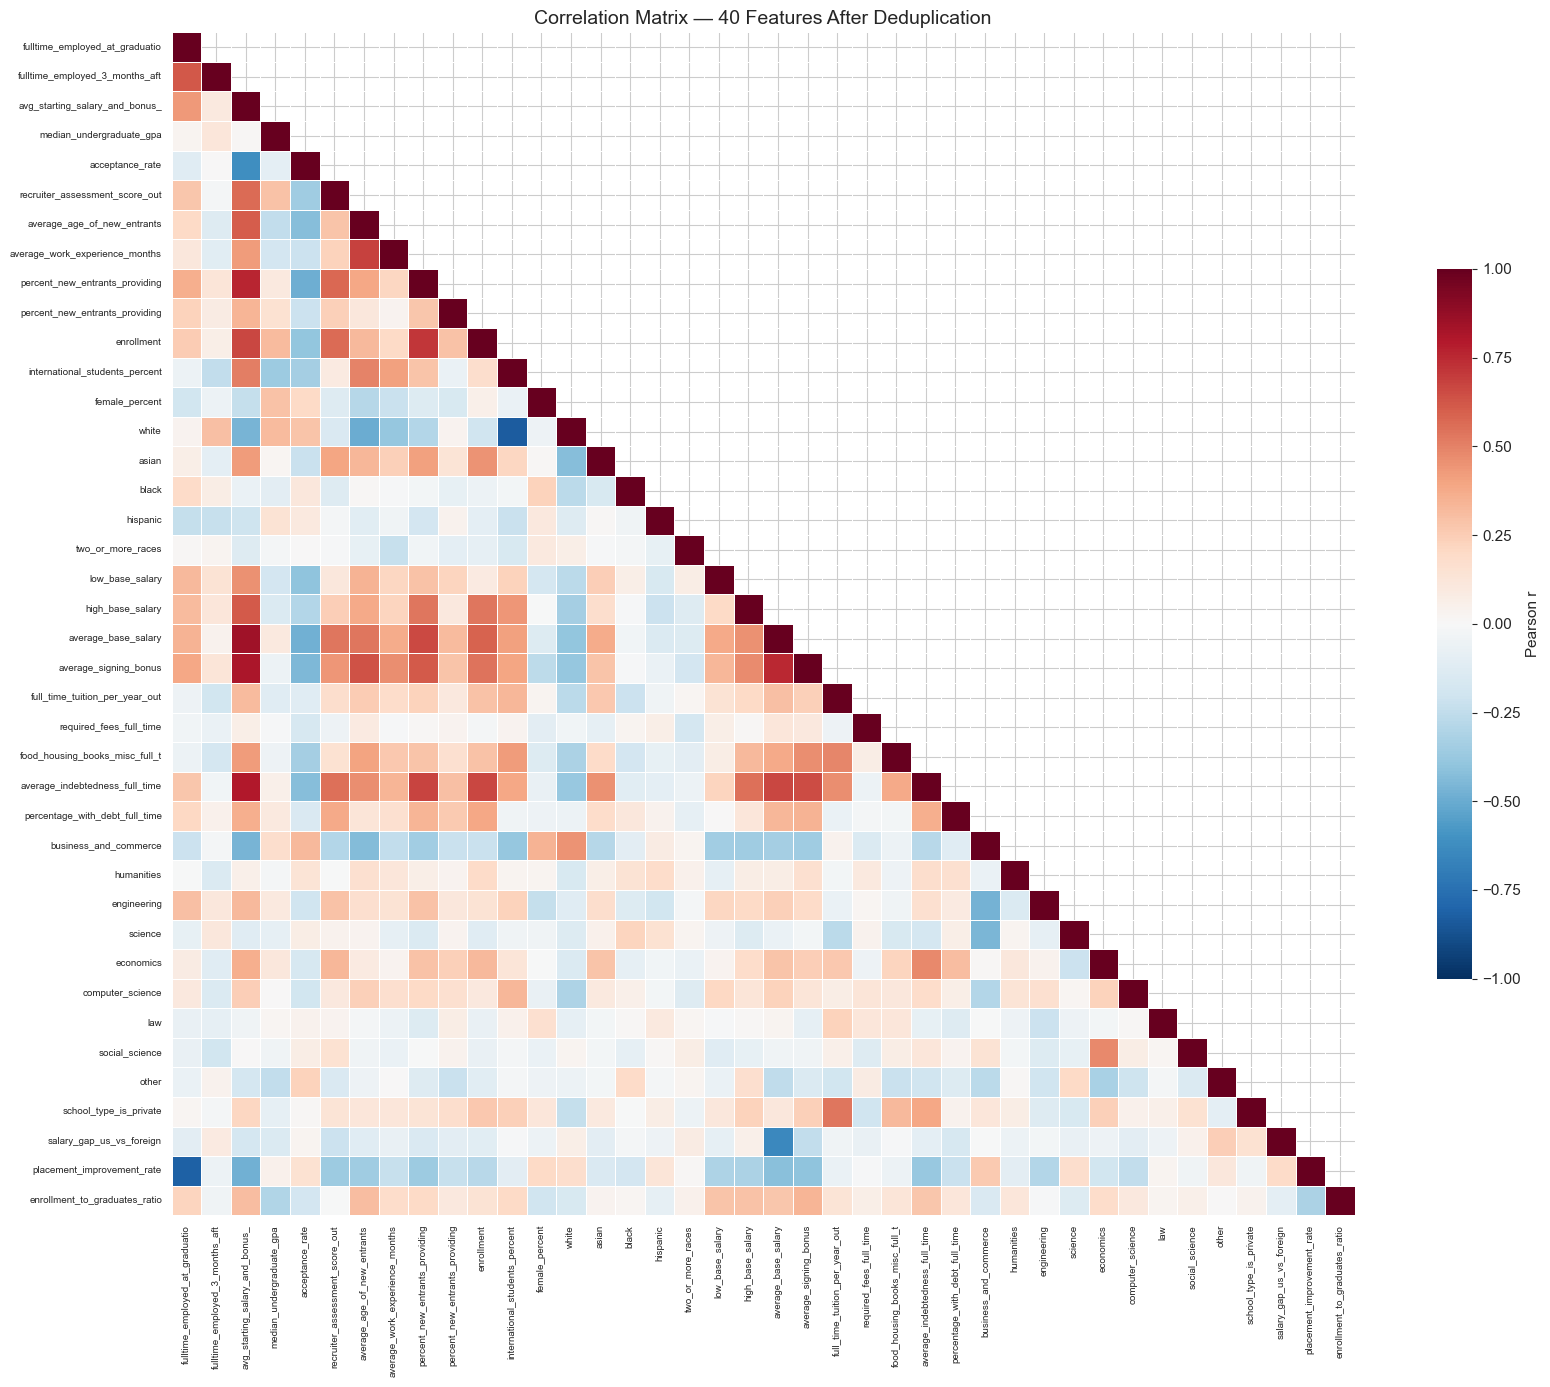

In [12]:
# Visualize the correlation matrix of final features
fig, ax = plt.subplots(figsize=(18, 14))
corr_final = df_deduped.corr()
# Create short names for readability
short_names = [c.split('.')[-1][:30] for c in df_deduped.columns]
mask = np.triu(np.ones_like(corr_final, dtype=bool), k=1)
sns.heatmap(corr_final, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=short_names, yticklabels=short_names,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'})
ax.set_title(f'Correlation Matrix — {df_deduped.shape[1]} Features After Deduplication', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## Step 1.8 — Feature Scaling (StandardScaler)

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_deduped)
df_scaled = pd.DataFrame(X_scaled, columns=df_deduped.columns, index=df_deduped.index)

print(f"Scaled feature matrix: {df_scaled.shape}")
print(f"Mean of each feature (should be ~0): {df_scaled.mean().abs().max():.2e}")
print(f"Std of each feature (should be ~1):  {df_scaled.std().mean():.4f}")

# Store the unscaled version for interpretable analysis later
df_unscaled = df_deduped.copy()

print(f"\nFinal clustering input: {df_scaled.shape[0]} schools x {df_scaled.shape[1]} features")

Scaled feature matrix: (121, 40)
Mean of each feature (should be ~0): 2.44e-15
Std of each feature (should be ~1):  1.0042

Final clustering input: 121 schools x 40 features


## Step 1.9 — PCA Visualization (for exploration, not clustering)

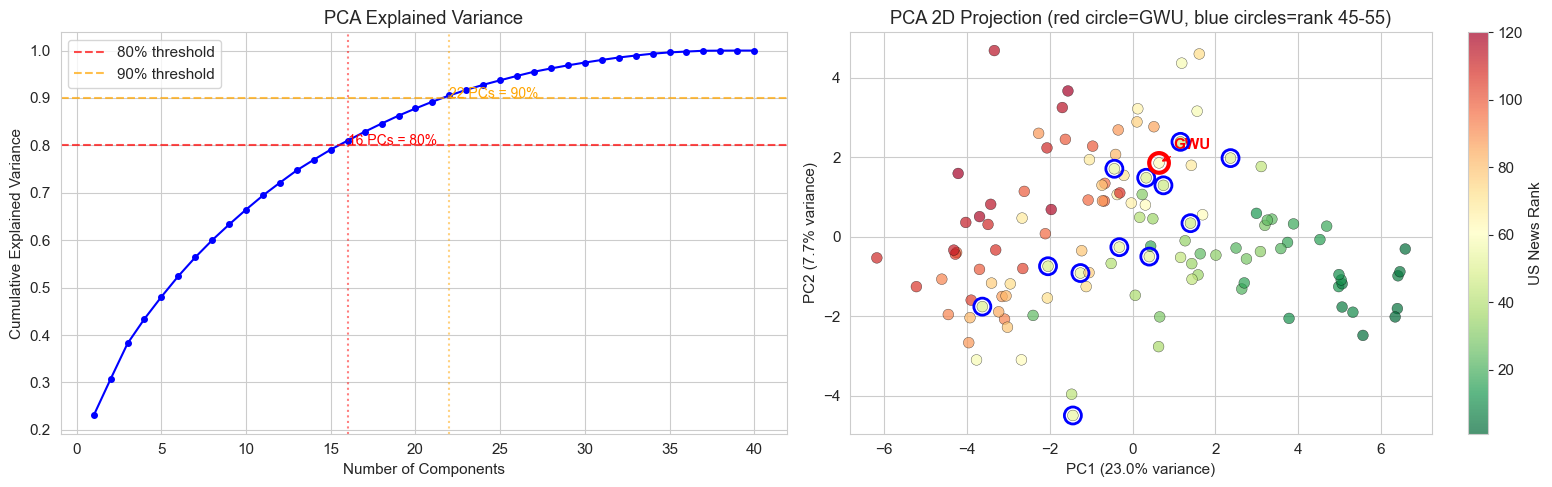


PCA summary: 16 components explain 80%, 22 components explain 90% of variance
PC1 explains 23.0%, PC2 explains 7.7%


In [14]:
# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cum_var)+1), cum_var, 'b-o', markersize=4)
axes[0].axhline(y=0.80, color='r', linestyle='--', alpha=0.7, label='80% threshold')
axes[0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
n_80 = np.argmax(cum_var >= 0.80) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
axes[0].axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
axes[0].axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()
axes[0].annotate(f'{n_80} PCs = 80%', xy=(n_80, 0.80), fontsize=10, color='r')
axes[0].annotate(f'{n_90} PCs = 90%', xy=(n_90, 0.90), fontsize=10, color='orange')

# 2D PCA scatter
ranks = labels['rank'].values
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=ranks, cmap='RdYlGn_r', 
                          s=60, alpha=0.7, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, ax=axes[1], label='US News Rank')

# Label GWU
gwu_idx = np.where(gwu_mask.values)[0][0]
axes[1].scatter(X_pca[gwu_idx, 0], X_pca[gwu_idx, 1], c='none', s=200, 
               edgecolors='red', linewidth=3, zorder=5)
axes[1].annotate('GWU', xy=(X_pca[gwu_idx, 0], X_pca[gwu_idx, 1]),
                xytext=(10, 10), textcoords='offset points', fontsize=11,
                fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

# Label rank 45-55 schools
rank_target_mask = (ranks >= 45) & (ranks <= 55)
for idx in np.where(rank_target_mask)[0]:
    axes[1].scatter(X_pca[idx, 0], X_pca[idx, 1], c='none', s=150,
                   edgecolors='blue', linewidth=2, zorder=4)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('PCA 2D Projection (red circle=GWU, blue circles=rank 45-55)')

plt.tight_layout()
plt.show()

print(f"\nPCA summary: {n_80} components explain 80%, {n_90} components explain 90% of variance")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%}, PC2 explains {pca.explained_variance_ratio_[1]:.1%}")

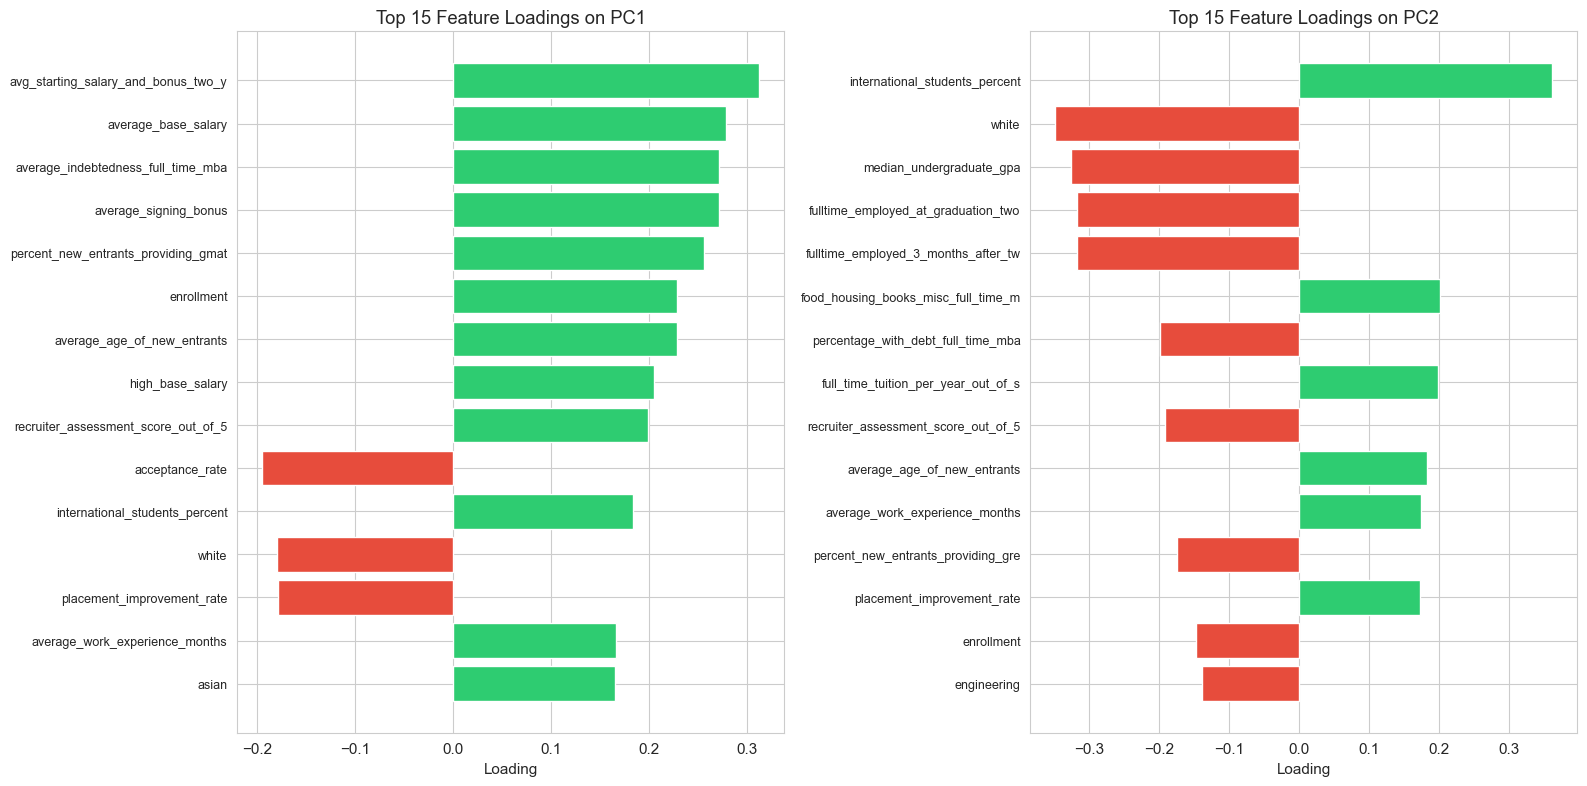

In [15]:
# Top feature loadings on PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=df_deduped.columns)
loadings['short_name'] = [c.split('.')[-1][:35] for c in loadings.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, pc in enumerate(['PC1', 'PC2']):
    top = loadings[pc].abs().nlargest(15)
    vals = loadings.loc[top.index, pc]
    names = loadings.loc[top.index, 'short_name']
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in vals]
    axes[i].barh(range(len(vals)), vals.values, color=colors)
    axes[i].set_yticks(range(len(vals)))
    axes[i].set_yticklabels(names, fontsize=9)
    axes[i].set_xlabel('Loading')
    axes[i].set_title(f'Top 15 Feature Loadings on {pc}')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 1.10 — Save Outputs for Downstream Notebooks

In [16]:
import pickle

# Save all artifacts needed by downstream notebooks
artifacts = {
    'df_scaled': df_scaled,          # Scaled feature matrix (for clustering)
    'df_unscaled': df_unscaled,      # Unscaled imputed features (for interpretable analysis)
    'labels': labels,                 # school_name, rank, school_type
    'target': target,                 # overall_score (held out)
    'scaler': scaler,                 # StandardScaler (for inverse transforms)
    'pca': pca,                       # Fitted PCA object
    'X_pca': X_pca,                   # PCA-transformed data
    'gwu_name': gwu_name,            # GWU's school name string
    'gwu_idx': gwu_idx,              # GWU's integer index
    'feature_groups': {
        'A_ranking': [c for c in GROUP_A if c in df_scaled.columns],
        'B_admissions': [c for c in GROUP_B if c in df_scaled.columns],
        'C_demographics': [c for c in GROUP_C if c in df_scaled.columns],
        'D_career': [c for c in GROUP_D if c in df_scaled.columns],
        'E_salary': [c for c in GROUP_E if c in df_scaled.columns],
        'F_tuition': [c for c in GROUP_F if c in df_scaled.columns],
        'G_undergrad_majors': [c for c in GROUP_G if c in df_scaled.columns],
        'H_derived': [c for c in GROUP_H if c in df_scaled.columns],
    },
    'FEATURES_TO_DROP': FEATURES_TO_DROP,
    'TARGET_COL': TARGET_COL,
}

with open('feature_engineering_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Saved: feature_engineering_artifacts.pkl")
print(f"\nArtifacts summary:")
print(f"  df_scaled:   {df_scaled.shape} (clustering input)")
print(f"  df_unscaled: {df_unscaled.shape} (interpretable)")
print(f"  labels:      {labels.shape}")
print(f"  target:      {target.shape}")
print(f"  GWU:         '{gwu_name}' (index {gwu_idx})")
print(f"\nFeature groups in final matrix:")
for grp, cols in artifacts['feature_groups'].items():
    print(f"  {grp}: {len(cols)} features")

Saved: feature_engineering_artifacts.pkl

Artifacts summary:
  df_scaled:   (121, 40) (clustering input)
  df_unscaled: (121, 40) (interpretable)
  labels:      (121, 3)
  target:      (121,)
  GWU:         'George Washington University' (index 31)

Feature groups in final matrix:
  A_ranking: 6 features
  B_admissions: 4 features
  C_demographics: 8 features
  D_career: 0 features
  E_salary: 4 features
  F_tuition: 5 features
  G_undergrad_majors: 9 features
  H_derived: 4 features


## Summary

| Step | Action | Result |
|------|--------|--------|
| 1.1 | Load raw CSV | 121 schools x 228 columns |
| 1.2 | Select features (Groups A-G) | 47 raw features |
| 1.3 | Parse tuition strings | Numeric tuition values |
| 1.4 | Create derived features (Group H) | +4 = 51 features |
| 1.5 | GMAT cross-ref + regression imputation | GMAT gaps filled |
| 1.6 | KNN imputation (k=5) | Zero remaining NaN |
| 1.7 | Correlation dedup (|r| > 0.85) | ~45 features |
| 1.8 | StandardScaler | Mean=0, Std=1 |
| 1.9 | PCA visualization | Variance explained plotted |
| 1.10 | Save artifacts | `feature_engineering_artifacts.pkl` |

**Next:** `02_clustering_analysis.ipynb` — uses `df_scaled` from the pickle file.